In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.plot import plotting_extent

In [3]:
# Detect the project root whether the notebook starts in the root
# directory or inside the notebooks directory.
current_directory = Path.cwd()

if (current_directory / "data").exists():
    project_root = current_directory
else:
    project_root = current_directory.parent

red_path = (
    project_root
    / "data"
    / "raw"
    / "sentinel2"
    / "2025-08-02"
    / "B04_2025-08-02.tif"
)

nir_path = (
    project_root
    / "data"
    / "raw"
    / "sentinel2"
    / "2025-08-02"
    / "B08_2025-08-02.tif"
)

print("Project root:", project_root)
print("Red band exists:", red_path.exists())
print("NIR band exists:", nir_path.exists())

Project root: /Users/eleazar/Documents/wetland-change-manitoba
Red band exists: True
NIR band exists: True


In [4]:
with rasterio.open(red_path) as red_src:
    print("B04 — Red band")
    print("CRS:", red_src.crs)
    print("Dimensions:", red_src.width, "x", red_src.height)
    print("Band count:", red_src.count)
    print("Data type:", red_src.dtypes[0])
    print("Resolution:", red_src.res)
    print("Bounds:", red_src.bounds)
    print("NoData value:", red_src.nodata)

print()

with rasterio.open(nir_path) as nir_src:
    print("B08 — Near-infrared band")
    print("CRS:", nir_src.crs)
    print("Dimensions:", nir_src.width, "x", nir_src.height)
    print("Band count:", nir_src.count)
    print("Data type:", nir_src.dtypes[0])
    print("Resolution:", nir_src.res)
    print("Bounds:", nir_src.bounds)
    print("NoData value:", nir_src.nodata)

B04 — Red band
CRS: EPSG:32614
Dimensions: 2500 x 1253
Band count: 1
Data type: uint16
Resolution: (15.565620840399992, 16.26303070550673)
Bounds: BoundingBox(left=612005.802059, bottom=5561042.057073, right=650919.85416, top=5581419.634547)
NoData value: None

B08 — Near-infrared band
CRS: EPSG:32614
Dimensions: 2500 x 1253
Band count: 1
Data type: uint16
Resolution: (15.565620840399992, 16.26303070550673)
Bounds: BoundingBox(left=612005.802059, bottom=5561042.057073, right=650919.85416, top=5581419.634547)
NoData value: None


In [5]:
with rasterio.open(red_path) as red_src, rasterio.open(nir_path) as nir_src:
    same_crs = red_src.crs == nir_src.crs
    same_shape = (
        red_src.width == nir_src.width
        and red_src.height == nir_src.height
    )
    same_transform = red_src.transform == nir_src.transform
    same_bounds = red_src.bounds == nir_src.bounds

print("Same CRS:", same_crs)
print("Same dimensions:", same_shape)
print("Same transform:", same_transform)
print("Same bounds:", same_bounds)

Same CRS: True
Same dimensions: True
Same transform: True
Same bounds: True


In [6]:
with rasterio.open(red_path) as red_src:
    red = red_src.read(1, masked=True).astype("float32")
    raster_profile = red_src.profile.copy()
    raster_transform = red_src.transform

with rasterio.open(nir_path) as nir_src:
    nir = nir_src.read(1, masked=True).astype("float32")

print("Red array shape:", red.shape)
print("NIR array shape:", nir.shape)

print()
print("Red minimum:", red.min())
print("Red maximum:", red.max())
print("NIR minimum:", nir.min())
print("NIR maximum:", nir.max())

Red array shape: (1253, 2500)
NIR array shape: (1253, 2500)

Red minimum: 0.0
Red maximum: 54584.0
NIR minimum: 0.0
NIR maximum: 53555.0


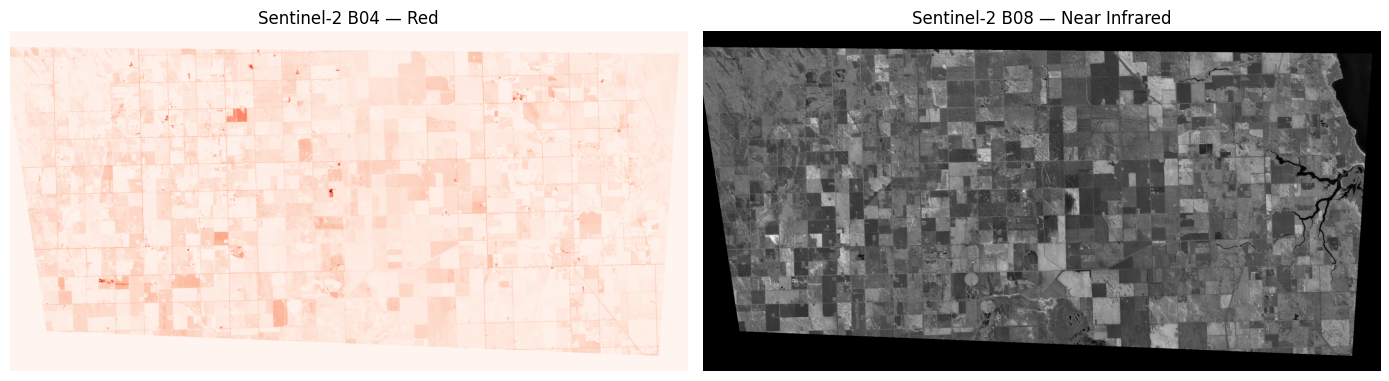

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(red, cmap="Reds")
axes[0].set_title("Sentinel-2 B04 — Red")
axes[0].axis("off")

axes[1].imshow(nir, cmap="gray")
axes[1].set_title("Sentinel-2 B08 — Near Infrared")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [9]:
denominator = nir + red

with np.errstate(divide="ignore", invalid="ignore"):
    ndvi = (nir - red) / denominator

# Mask pixels where the denominator is zero and preserve the
# existing masks from the source rasters.
invalid_pixels = (
    (denominator == 0)
    | np.ma.getmaskarray(red)
    | np.ma.getmaskarray(nir)
)

ndvi = np.ma.array(ndvi, mask=invalid_pixels)
ndvi = np.ma.clip(ndvi, -1, 1)

print("NDVI minimum:", ndvi.min())
print("NDVI maximum:", ndvi.max())
print("NDVI mean:", ndvi.mean())

NDVI minimum: -1.0
NDVI maximum: 0.9858537
NDVI mean: 0.6009170746909736


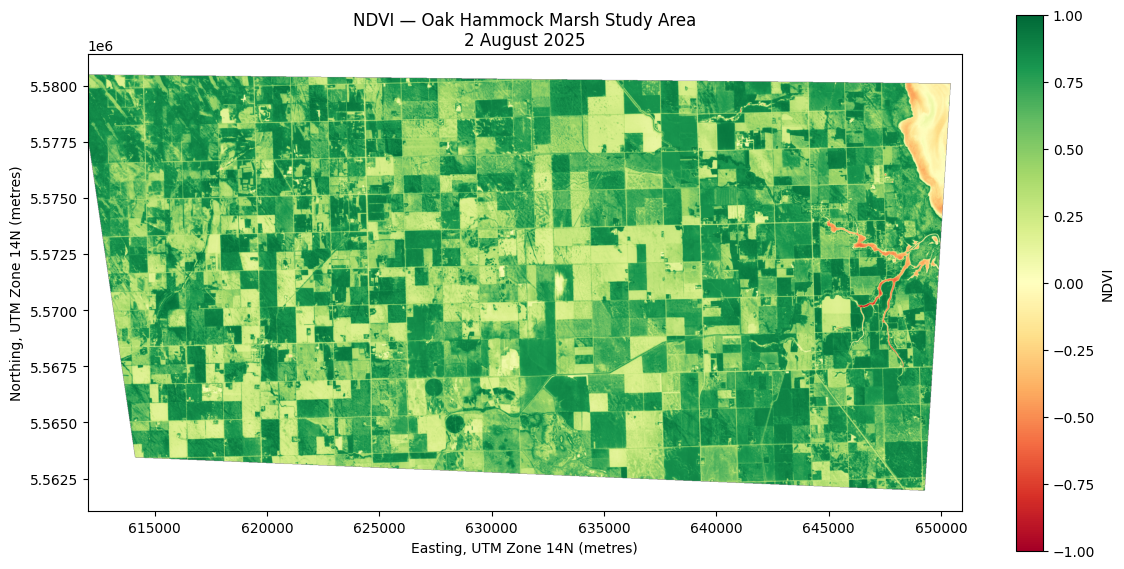

In [10]:
raster_extent = plotting_extent(red, raster_transform)

fig, ax = plt.subplots(figsize=(12, 7))

image = ax.imshow(
    ndvi,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1,
    extent=raster_extent,
    origin="upper",
)

ax.set_title("NDVI — Oak Hammock Marsh Study Area\n2 August 2025")
ax.set_xlabel("Easting, UTM Zone 14N (metres)")
ax.set_ylabel("Northing, UTM Zone 14N (metres)")

colorbar = fig.colorbar(image, ax=ax, shrink=0.8)
colorbar.set_label("NDVI")

plt.tight_layout()
plt.show()

In [11]:
processed_directory = project_root / "data" / "processed"
processed_directory.mkdir(parents=True, exist_ok=True)

ndvi_output_path = processed_directory / "ndvi_2025-08-02.tif"

ndvi_nodata = -9999.0
ndvi_to_save = ndvi.filled(ndvi_nodata).astype("float32")

raster_profile.update(
    dtype="float32",
    count=1,
    nodata=ndvi_nodata,
    compress="lzw",
)

with rasterio.open(
    ndvi_output_path,
    "w",
    **raster_profile,
) as destination:
    destination.write(ndvi_to_save, 1)

print("NDVI saved to:")
print(ndvi_output_path)

NDVI saved to:
/Users/eleazar/Documents/wetland-change-manitoba/data/processed/ndvi_2025-08-02.tif
